# 🛰 Thermal Stress & Transport Poverty Inside the Italian Cities
**SEEOB – Politecnico di Milano | Transform Transport**

> Set `CITY` in Cell 1 and run all cells (`Runtime → Run all`)

**Outputs saved automatically to Google Drive → `SEEOB_TransportPoverty/`**

In [ ]:
from google.colab import drive, auth
drive.mount('/content/drive')
auth.authenticate_user()

import subprocess
subprocess.run(['pip','install','earthengine-api','folium','branca','-q'], check=True)

import ee, os, csv, pickle, hashlib, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import folium, folium.plugins
from IPython.display import display
warnings.filterwarnings('ignore')

ee.Initialize(project='ee-edoardo-polimi')

CITY       = 'Milano'   # Roma | Torino | Napoli | Bologna | Firenze
Buffer_rad = 500
THRESHOLD  = 32.0
START      = '2023-06-01'
END        = '2023-08-31'
DRIVE      = '/content/drive/MyDrive/SEEOB_TransportPoverty'
CACHE_DIR  = f'{DRIVE}/cache'
os.makedirs(DRIVE, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
print(f'Ready — {CITY}')


Mounted at /content/drive
Ready — Milano


# Earth Engine Data

In [ ]:
city_fc     = ee.FeatureCollection('FAO/GAUL/2015/level2').filter(ee.Filter.eq('ADM2_NAME', CITY))
region      = city_fc.geometry()
region_wide = region.buffer(5000)
b = region.bounds().getInfo()['coordinates'][0]
centre = [(min(p[1] for p in b)+max(p[1] for p in b))/2,
          (min(p[0] for p in b)+max(p[0] for p in b))/2]

water    = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('seasonality').gte(10).Not().unmask(1).clip(region)

# ── Urban mask via ESA WorldCover 10m ────────────────────────────────────────
# Class 50 = Built-up. All other classes (crops, forest, grassland, bare, etc.)

worldcover  = ee.ImageCollection('ESA/WorldCover/v200').first().clip(region)
urban_mask  = worldcover.eq(50)          \
                .And(water)              \
                .rename('urban_mask')    \
                .clip(region)
print('WorldCover urban mask ready')

def mask_s2(img):
    qa = img.select('QA60')
    m  = qa.bitwiseAnd(1<<10).eq(0).And(qa.bitwiseAnd(1<<11).eq(0))
    return img.updateMask(m).divide(10000).copyProperties(img, ['system:time_start'])

s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(region_wide).filterDate(START, END) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .map(mask_s2).median()

ndvi = s2.normalizedDifference(['B8','B4']).rename('NDVI').updateMask(water).clip(region)
ndwi = s2.normalizedDifference(['B3','B8']).rename('NDWI').updateMask(urban_mask).clip(region)
ndbi = s2.normalizedDifference(['B11','B8']).rename('NDBI').updateMask(urban_mask).clip(region)

lst = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterBounds(region).filterDate(START, END) \
    .select('LST_Day_1km').mean() \
    .multiply(0.02).subtract(273.15).rename('LST_C') \
    .updateMask(water).clip(region)

pop = ee.ImageCollection('WorldPop/GP/100m/pop') \
    .filterDate('2020-01-01','2021-01-01') \
    .filter(ee.Filter.eq('country','ITA')) \
    .first().rename('POP').clip(region)

print('EE layers ready')

_key   = hashlib.md5(f'{CITY}{START}{END}'.encode()).hexdigest()[:8]
_cache = f'{CACHE_DIR}/{CITY}_{_key}.pkl'
if os.path.exists(_cache):
    with open(_cache,'rb') as f: data = pickle.load(f)
    print(f'Loaded {len(data["NDVI"])} cached points')
else:
    print('Sampling 1000 points...')
    feats = ee.Image.cat([ndvi,ndwi,ndbi,lst,pop]).sample(
        region=region, scale=1000, numPixels=1000, seed=42, dropNulls=True
    ).getInfo()['features']
    data = {k:[] for k in ['NDVI','NDWI','NDBI','LST_C','POP']}
    for f in feats:
        for k in data: data[k].append(f['properties'].get(k, float('nan')))
    for k in data: data[k] = np.array(data[k], dtype=float)
    ok = np.all([np.isfinite(data[k]) for k in data], axis=0)
    for k in data: data[k] = data[k][ok]
    with open(_cache,'wb') as f: pickle.dump(data, f)
    print(f'{ok.sum()} points cached')


WorldCover urban mask ready
EE layers ready
Loaded 930 cached points


# Correlation

In [ ]:
indices, corr = ['NDVI','NDWI','NDBI'], {}
for idx in indices:
    r, p = stats.pearsonr(data[idx], data['LST_C'])
    corr[idx] = {'r':r, 'p':p}
    print(f'{idx} vs LST: r={r:+.4f}  p={p:.2e}')

X   = np.column_stack([data['NDVI'], data['NDWI'], data['NDBI']])
y   = data['LST_C']
mdl = LinearRegression().fit(X, y)
yp  = mdl.predict(X)
r2  = r2_score(y, yp)
rmse= np.sqrt(mean_squared_error(y, yp))
mae = np.mean(np.abs(y - yp))
res = y - yp

print(f'NDVI:{mdl.coef_[0]:+.4f}  NDWI:{mdl.coef_[1]:+.4f}  NDBI:{mdl.coef_[2]:+.4f}  intercept:{mdl.intercept_:+.4f}')
print(f'R2={r2:.4f}  RMSE={rmse:.4f}C  MAE={mae:.4f}C')

thr   = THRESHOLD
smask = yp > thr
print(f'Stress threshold: {thr:.2f}C  |  {smask.mean()*100:.1f}% of pixels')


NDVI vs LST: r=-0.7343  p=2.52e-158
NDWI vs LST: r=+0.7179  p=3.80e-148
NDBI vs LST: r=+0.7088  p=8.34e-143
NDVI:-10.1272  NDWI:-2.3811  NDBI:+1.3030  intercept:+36.5197
R2=0.5409  RMSE=1.3718C  MAE=1.0947C
Stress threshold: 32.00C  |  53.5% of pixels


# Figure

Saved: Milano_01_correlations.png


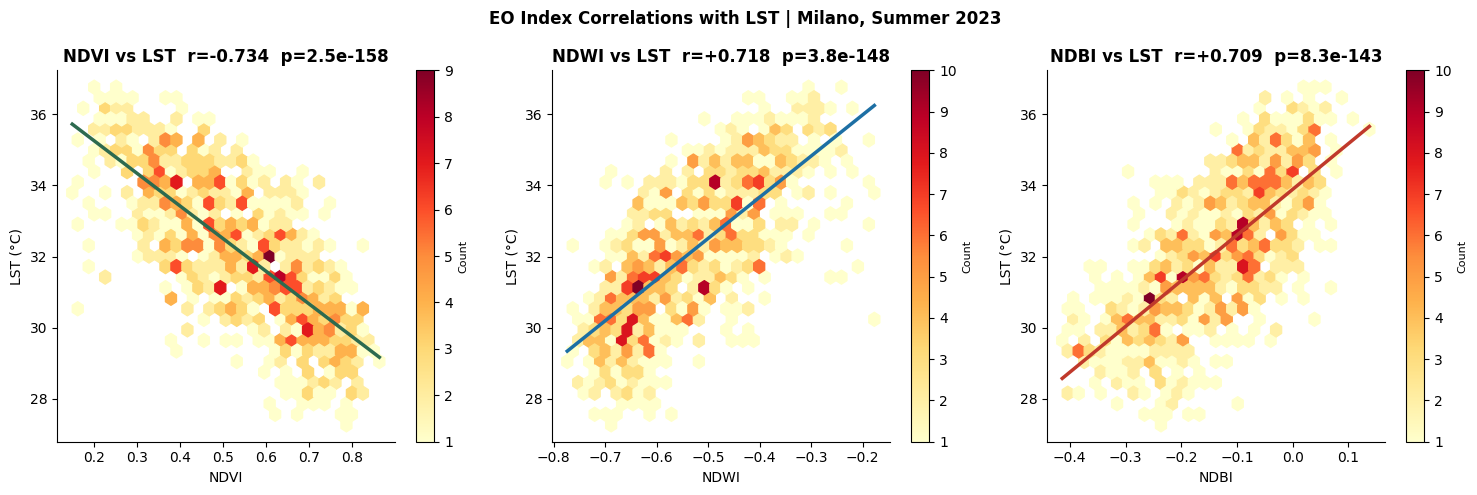

Saved: Milano_02_thermal_stress_pop.png


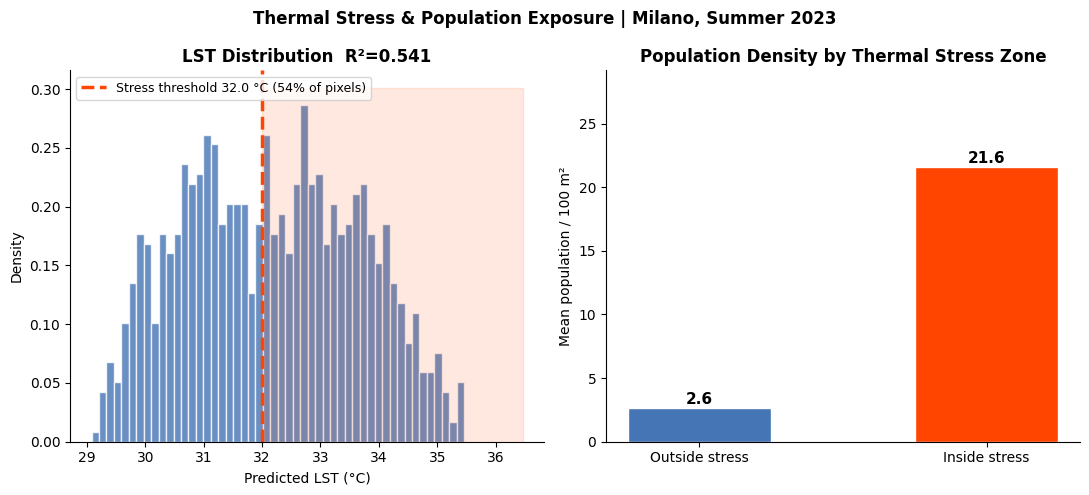

Figures done — removed diagnostics & residuals panels (kept correlations + stress/pop).


In [ ]:
plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
COLS = {'NDVI':'#2d6a4f','NDWI':'#1d6fa4','NDBI':'#c0392b'}

def save(fig, name):
    fig.savefig(f'{DRIVE}/{CITY}_{name}', dpi=150, bbox_inches='tight')
    print(f'Saved: {CITY}_{name}')
    plt.show(); plt.close()

# ── Fig 1  EO Correlations (hexbin + regression line, 1×3) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'EO Index Correlations with LST | {CITY}, Summer 2023', fontweight='bold')
for ax, idx in zip(axes, ['NDVI','NDWI','NDBI']):
    hb = ax.hexbin(data[idx], data['LST_C'], gridsize=28, cmap='YlOrRd', mincnt=1)
    plt.colorbar(hb, ax=ax).set_label('Count', fontsize=8)
    xi = np.linspace(data[idx].min(), data[idx].max(), 100)
    m2, b2 = np.polyfit(data[idx], data['LST_C'], 1)
    ax.plot(xi, m2*xi+b2, color=COLS[idx], lw=2.5)
    ax.set_title(f'{idx} vs LST  r={corr[idx]["r"]:+.3f}  p={corr[idx]["p"]:.1e}', fontweight='bold')
    ax.set_xlabel(idx); ax.set_ylabel('LST (°C)')
plt.tight_layout(); save(fig, '01_correlations.png')

# ── Fig 2  Thermal Stress — LST distribution + population exposure ───────────
pop_s  = data['POP'][smask];  pop_ns = data['POP'][~smask]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle(f'Thermal Stress & Population Exposure | {CITY}, Summer 2023', fontweight='bold')

# Left: LST distribution with threshold
axes[0].hist(yp, bins=50, color='#4575b4', edgecolor='white', alpha=0.8, density=True)
axes[0].axvline(thr, color='#FF4500', lw=2.5, ls='--',
                label=f'Stress threshold {thr:.1f} °C ({smask.mean()*100:.0f}% of pixels)')
axes[0].fill_betweenx([0, axes[0].get_ylim()[1] if axes[0].get_ylim()[1] > 0 else 0.5],
                       thr, yp.max()+1, color='#FF4500', alpha=0.12)
axes[0].set_xlabel('Predicted LST (°C)'); axes[0].set_ylabel('Density')
axes[0].set_title(f'LST Distribution  R²={r2:.3f}', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: mean pop density inside vs outside stress zone
vals  = [pop_ns.mean(), pop_s.mean()]
bars  = axes[1].bar(['Outside stress', 'Inside stress'], vals,
                    color=['#4575b4','#FF4500'], edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Mean population / 100 m²')
axes[1].set_title('Population Density by Thermal Stress Zone', fontweight='bold')
axes[1].set_ylim(0, max(vals)*1.35)
plt.tight_layout(); save(fig, '02_thermal_stress_pop.png')
print(f'Figures done — removed diagnostics & residuals panels (kept correlations + stress/pop).')


## Interactive Map + Public Transport Stops

In [ ]:
# ── 5a  Fetch PT stops from OSM ──────────────────────────────────────────────
import geopandas as gpd
from shapely.geometry import Point, shape

b        = region.bounds().getInfo()['coordinates'][0]
lat_min  = min(p[1] for p in b); lat_max = max(p[1] for p in b)
lon_min  = min(p[0] for p in b); lon_max = max(p[0] for p in b)
bbox_str = f'{lat_min:.4f},{lon_min:.4f},{lat_max:.4f},{lon_max:.4f}'
print(f'Bbox: {bbox_str}')

osm_query = f"""
[out:json][timeout:90];
(
  node["public_transport"="stop_position"]({bbox_str});
  node["highway"="bus_stop"]({bbox_str});
  node["railway"~"station|halt|tram_stop"]({bbox_str});
  node["station"="subway"]({bbox_str});
);
out body;
"""
MIRRORS = [
    'https://overpass-api.de/api/interpreter',
    'https://overpass.kumi.systems/api/interpreter',
    'https://maps.mail.ru/osm/tools/overpass/api/interpreter',
]
elements = []
for mirror in MIRRORS:
    try:
        resp = requests.post(mirror, data=osm_query.encode(),
                             headers={'Content-Type':'application/x-www-form-urlencoded',
                                      'User-Agent':'SEEOB-Polimi/1.0'}, timeout=90)
        if resp.status_code == 200:
            elements = resp.json().get('elements', [])
            print(f'Got {len(elements)} OSM nodes from {mirror}'); break
        else:
            print(f'  {mirror}: HTTP {resp.status_code}')
    except Exception as e:
        print(f'  {mirror}: {e}')

stops_gdf = None
pt_coverage = pt_gap = None
if elements:
    rows = []
    for el in elements:
        tags = el.get('tags', {})
        if   tags.get('station') == 'subway' or tags.get('subway') == 'yes': mode = 'metro'
        elif tags.get('railway') in ('station','halt'):                        mode = 'rail'
        elif tags.get('railway') == 'tram_stop':                               mode = 'tram'
        elif tags.get('highway') == 'bus_stop':                                mode = 'bus'
        else:                                                                    mode = 'other'
        rows.append({'lat':el['lat'],'lon':el['lon'],
                     'name':tags.get('name',''),'mode':mode})
    stops_gdf  = gpd.GeoDataFrame(rows,
                    geometry=[Point(r['lon'],r['lat']) for r in rows], crs='EPSG:4326')
    city_poly  = shape(city_fc.getInfo()['features'][0]['geometry'])
    stops_gdf  = stops_gdf[stops_gdf.geometry.within(city_poly)].copy()
    print('Mode breakdown:\n' + stops_gdf['mode'].value_counts().to_string())
    print(f'Total stops inside {CITY}: {len(stops_gdf)}')

    # 400m pedestrian catchment
    stops_proj   = stops_gdf.to_crs(epsg=32632)
    buf          = stops_proj.copy(); buf['geometry'] = stops_proj.buffer(800)
    pt_coverage  = buf.dissolve().to_crs(epsg=4326)

    # ── Clean geometry: dissolve can produce GeometryCollections (mixed
    #    Polygon + LineString slivers) which gpd.overlay refuses to handle.
    #    buffer(0) repairs self-intersections; explode() + query keeps only
    #    polygonal parts (Polygon / MultiPolygon). ──────────────────────────
    pt_coverage['geometry'] = pt_coverage['geometry'].buffer(0)
    pt_coverage = (pt_coverage.explode(index_parts=False)
                               .loc[lambda g: g.geometry.geom_type
                                              .isin(['Polygon','MultiPolygon'])]
                               .dissolve()
                               .reset_index(drop=True))

    city_gdf     = gpd.GeoDataFrame(geometry=[city_poly], crs='EPSG:4326')
    # Also clean city boundary for safety
    city_gdf['geometry'] = city_gdf['geometry'].buffer(0)
    pt_gap       = gpd.overlay(city_gdf, pt_coverage, how='difference')
    city_km2     = city_gdf.to_crs(epsg=32632).area.sum()/1e6
    cov_km2      = pt_coverage.to_crs(epsg=32632).area.sum()/1e6
    gap_km2      = pt_gap.to_crs(epsg=32632).area.sum()/1e6
    print(f'City {city_km2:.1f} km²  |  Covered {cov_km2:.1f} km² ({cov_km2/city_km2*100:.1f}%)  |  Gap {gap_km2:.1f} km² ({gap_km2/city_km2*100:.1f}%)')
    stops_gdf.to_file(f'{DRIVE}/{CITY}_pt_stops.geojson',        driver='GeoJSON')
    pt_coverage.to_file(f'{DRIVE}/{CITY}_pt_coverage_800m.geojson', driver='GeoJSON')
    pt_gap.to_file(f'{DRIVE}/{CITY}_pt_gap_800m.geojson',         driver='GeoJSON')
else:
    print('OSM unavailable — PT layers will be skipped from the map')

# ── 5b  Build GEE tile layers ─────────────────────────────────────────────────
TPAL = ['313695','4575b4','74add1','abd9e9','fee090','fdae61','f46d43','d73027','a50026']
def tile(img, vis):
    return img.getMapId(vis)['tile_fetcher'].url_format

lst_pred    = (ndvi.multiply(float(mdl.coef_[0]))
               .add(ndwi.multiply(float(mdl.coef_[1])))
               .add(ndbi.multiply(float(mdl.coef_[2])))
               .add(ee.Image.constant(float(mdl.intercept_)))
               .rename('LST_pred_C').updateMask(urban_mask).clip(region))
stress_img  = lst_pred.gt(float(thr)).selfMask()
pop_str_img = pop.updateMask(stress_img)

# WorldCover classes for map reference
# 10=Tree cover, 20=Shrubland, 30=Grassland, 40=Cropland, 50=Built-up
non_urban_display = worldcover.neq(50).selfMask().clip(region)

# Stressed area NOT covered by PT (double-disadvantaged)
if pt_gap is not None:
    try:
        gap_ee     = ee.FeatureCollection([ee.Feature(ee.Geometry(f['geometry']))                                           for f in pt_gap.__geo_interface__['features']])
        gap_mask   = ee.Image.constant(1).clip(gap_ee)
        stress_pt_gap = stress_img.updateMask(gap_mask).rename('Stress_NoPT')
    except Exception as e:
        stress_pt_gap = None
        print(f'Double-disadvantage layer skipped: {e}')
else:
    stress_pt_gap = None

# ── 5c  Assemble Folium map ───────────────────────────────────────────────────
m = folium.Map(location=centre, zoom_start=11, tiles=None)
folium.TileLayer('CartoDB positron',    name='Light',     overlay=False, show=True ).add_to(m)
folium.TileLayer('CartoDB dark_matter', name='Dark',      overlay=False, show=False).add_to(m)
folium.TileLayer('https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
                 attr='Google', name='Satellite', overlay=False, show=False).add_to(m)

GEE_LAYERS = [
    ('NDVI 10m',      ndvi,       {'min':-0.1,'max':0.8,'palette':['d73027','f46d43','fdae61','fee08b','d9ef8b','a6d96a','66bd63','1a9850']}, False),
    ('NDWI 10m',      ndwi,       {'min':-0.5,'max':0.3,'palette':['8B4513','f5f5dc','00bfff','0000cd']}, False),
    ('NDBI 10m',      ndbi,       {'min':-0.3,'max':0.3,'palette':['1a9850','f7f7f7','b2182b']}, False),
    ('LST MODIS 1km', lst,        {'min':25,'max':45,'palette':TPAL}, False),
    ('LST Pred 10m',  lst_pred,   {'min':25,'max':45,'palette':TPAL}, True),
    ('Population',    pop,        {'min':0,'max':300,'palette':['f7fbff','c6dbef','6baed6','2171b5','08306b']}, False),
    ('Non-urban (WorldCover)', non_urban_display,
     {'min':0, 'max':1,
      'palette':['#1a9850']}, False),  # green = masked-out non-built pixels
    ('Thermal Stress',stress_img, {'min':0,'max':1,'palette':['FF4500']}, True),
    ('Pop in Stress',  pop_str_img,{'min':0,'max':200,'palette':['ffffb2','fecc5c','fd8d3c','f03b20','bd0026']}, True),
]
if stress_pt_gap is not None:
    GEE_LAYERS.append(('Stress + No PT Access', stress_pt_gap, {'min':0,'max':1,'palette':['7B0000']}, True))

for name, img, vis, show in GEE_LAYERS:
    try:
        folium.TileLayer(tiles=tile(img, vis), attr='GEE', name=name,
                         overlay=True, show=show, opacity=0.75).add_to(m)
        print(f'Added GEE: {name}')
    except Exception as e:
        print(f'Skip {name}: {e}')

# City boundary
try:
    folium.GeoJson(city_fc.getInfo(), name=f'{CITY} Boundary',
        style_function=lambda x: {'fillColor':'none','color':'#FFD700','weight':2.5}
    ).add_to(m)
except: pass

# PT layers
if stops_gdf is not None:
    MODE_COLORS = {'bus':'#3498db','tram':'#2ecc71','metro':'#e74c3c',
                   'rail':'#9b59b6','other':'#95a5a6'}
    folium.GeoJson(pt_coverage.__geo_interface__, name='PT Coverage 800m',
        style_function=lambda x: {'fillColor':'#2ecc71','color':'#27ae60',
                                   'weight':1,'fillOpacity':0.18},
        show=False).add_to(m)
    folium.GeoJson(pt_gap.__geo_interface__, name='PT Gap >800m',
        style_function=lambda x: {'fillColor':'#e74c3c','color':'#c0392b',
                                   'weight':1,'fillOpacity':0.28},
        show=False).add_to(m)
    # Stop markers (sampled for performance)
    stops_sample = stops_gdf.sample(min(500, len(stops_gdf)), random_state=42)
    fg_stops = folium.FeatureGroup(name='PT Stops', show=True)
    for _, row in stops_sample.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']], radius=4,
            color='white', fill=True,
            fill_color=MODE_COLORS.get(row['mode'], '#95a5a6'),
            fill_opacity=0.9,
            popup=folium.Popup(f"{row['name'] or 'Stop'}<br>{row['mode']}", max_width=150),
            tooltip=row['mode']
        ).add_to(fg_stops)
    fg_stops.add_to(m)
    print(f'Added PT layers: {len(stops_gdf)} stops, coverage, gaps')

# Controls
folium.LayerControl(collapsed=False, position='topright').add_to(m)
folium.plugins.Fullscreen(position='topleft').add_to(m)
folium.plugins.MeasureControl(position='topleft').add_to(m)

m.save(f'{DRIVE}/{CITY}_map.html')
print('Map saved to Drive')
display(m)


Bbox: 45.2659,8.7075,45.7447,9.5514
Got 15012 OSM nodes from https://overpass-api.de/api/interpreter
Mode breakdown:
mode
bus      7087
other    4635
tram      827
metro     417
rail       95
Total stops inside Milano: 13061
City 1963.0 km²  |  Covered 1235.6 km² (62.9%)  |  Gap 745.6 km² (38.0%)
Added GEE: NDVI 10m
Added GEE: NDWI 10m
Added GEE: NDBI 10m
Added GEE: LST MODIS 1km
Added GEE: LST Pred 10m
Added GEE: Population
Added GEE: Non-urban (WorldCover)
Added GEE: Thermal Stress
Added GEE: Pop in Stress
Added GEE: Stress + No PT Access
Added PT layers: 13061 stops, coverage, gaps
Map saved to Drive


## Ground Sensor Validation (NOAA GSOD)

Validates the downscaled 10m LST against independent ground measurements
from NOAA's Global Surface Summary of Day (GSOD) network.

**Method:**
1. Find all GSOD stations within the city boundary
2. Download daily mean temperature for the analysis period
3. For each station, extract the predicted LST at that location
4. Compare: compute bias, RMSE, Pearson r between LST_pred and T_air
5. Plot station locations on the map

> ⚠️ **Note:** Air temperature (T_air) ≠ Land Surface Temperature (LST).
> LST is typically 5–15°C higher than T_air on hot summer days over urban surfaces.
> Validation here compares **spatial anomalies** (relative hot/cold patterns),
> not absolute values.



══════════  THERMAL STRESS × TRANSPORT ACCESS  ══════════
  Hot + No PT           32 pts ( 9.2%)
  Hot + PT             287 pts (82.5%)
  Cool + No PT           8 pts ( 2.3%)
  Cool + PT             21 pts ( 6.0%)

  → 10.0% of thermally stressed areas lack nearby PT
  → Double-disadvantaged (hot + no PT): 32/348 pixels (9.2% of city)
  → Mean LST in PT gaps:    32.91 °C
  → Mean LST in PT coverage:33.49 °C  (Δ = -0.59 °C)
  ⚠  Moderate overlap — targeted PT/cooling investment warranted | No systematic LST difference by PT access
══════════════════════════════════════════════════════════
Saved: Milano_03_stress_vs_transport.png


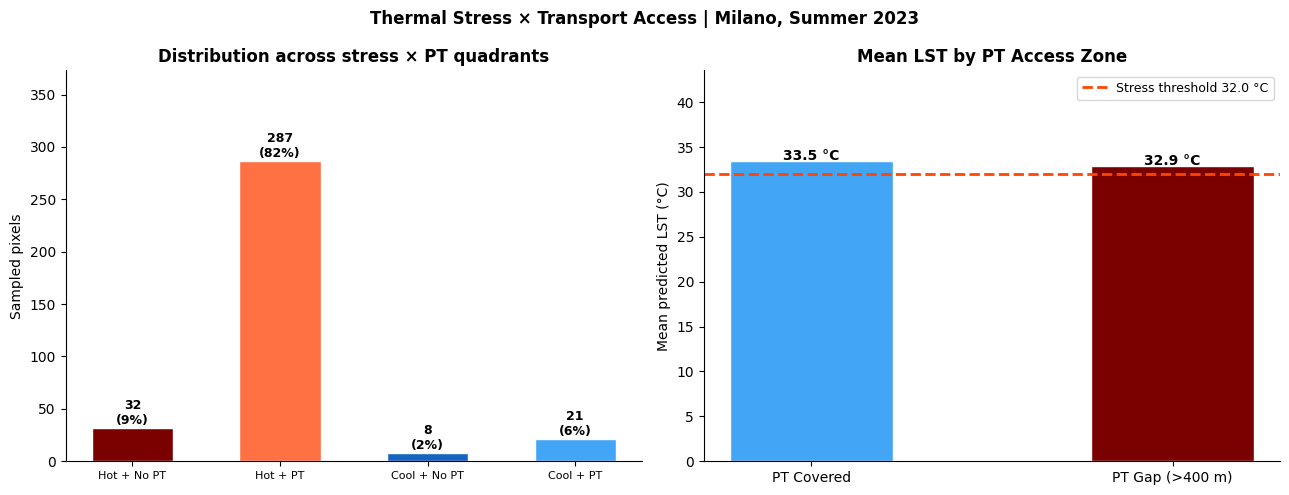

In [ ]:
# ── Thermal Stress × Transport Access Analysis ───────────────────────────────
import warnings; warnings.filterwarnings('ignore')

if stops_gdf is None or pt_gap is None:
    print('PT data not available — run Cell 5 first with working OSM access.')
else:
    try:
        # Re-sample 1000 points WITH coordinates via pixelLonLat
        coords_img  = ee.Image.pixelLonLat().clip(region)
        coord_feats = ee.Image.cat([coords_img, lst_pred]).sample(
            region=region, scale=1000, numPixels=1000, seed=42, dropNulls=True
        ).getInfo()['features']
        pts_data = [{'lat': f['properties']['latitude'],
                     'lon': f['properties']['longitude'],
                     'lst': f['properties']['LST_pred_C']} for f in coord_feats]
        pts_gdf = gpd.GeoDataFrame(pts_data,
                    geometry=[Point(r['lon'], r['lat']) for r in pts_data],
                    crs='EPSG:4326')
        pts_gdf['stressed'] = pts_gdf['lst'] > float(thr)

        # ── Fix: rebuild pt_coverage with a plain column for sjoin ───────
        cov_for_join = pt_coverage.copy().reset_index(drop=True)
        cov_for_join['covered'] = True
        # sjoin expects a simple GeoDataFrame — keep only geometry + covered
        cov_for_join = cov_for_join[['geometry','covered']]

        joined = gpd.sjoin(pts_gdf, cov_for_join, how='left', predicate='within')
        pts_gdf['covered'] = joined['covered'].fillna(False).values

        # 4 quadrants
        q = {
            'Hot + No PT':  pts_gdf[ pts_gdf['stressed'] & ~pts_gdf['covered']],
            'Hot + PT':     pts_gdf[ pts_gdf['stressed'] &  pts_gdf['covered']],
            'Cool + No PT': pts_gdf[~pts_gdf['stressed'] & ~pts_gdf['covered']],
            'Cool + PT':    pts_gdf[~pts_gdf['stressed'] &  pts_gdf['covered']],
        }
        counts = {k: len(v) for k, v in q.items()}
        total  = sum(counts.values())

        print('\n══════════  THERMAL STRESS × TRANSPORT ACCESS  ══════════')
        for k, n in counts.items():
            print(f'  {k:<18} {n:>5} pts ({n/total*100:4.1f}%)')

        hot_nopt    = counts['Hot + No PT']
        hot_tot     = counts['Hot + No PT'] + counts['Hot + PT']
        pt_gap_pct  = hot_nopt / hot_tot * 100 if hot_tot > 0 else 0

        mean_lst_gap = pts_gdf[~pts_gdf['covered']]['lst'].mean()
        mean_lst_cov = pts_gdf[ pts_gdf['covered']]['lst'].mean()
        delta        = mean_lst_gap - mean_lst_cov

        print(f'\n  → {pt_gap_pct:.1f}% of thermally stressed areas lack nearby PT')
        print(f'  → Double-disadvantaged (hot + no PT): {hot_nopt}/{total} pixels ({hot_nopt/total*100:.1f}% of city)')
        print(f'  → Mean LST in PT gaps:    {mean_lst_gap:.2f} °C')
        print(f'  → Mean LST in PT coverage:{mean_lst_cov:.2f} °C  (Δ = {delta:+.2f} °C)')

        if   hot_nopt / total > 0.10: flag = '⚠  Significant transport poverty in heat-stressed zones'
        elif hot_nopt / total > 0.04: flag = '⚠  Moderate overlap — targeted PT/cooling investment warranted'
        else:                          flag = '✓  Most stressed areas are PT-covered; thermal risk remains'
        if   delta > 1.0:  flag += f' | PT gaps are {delta:.1f} °C hotter — spatial inequity confirmed'
        elif delta > 0:    flag += f' | PT gaps slightly warmer (+{delta:.2f} °C)'
        else:              flag += f' | No systematic LST difference by PT access'
        print(f'  {flag}')
        print('══════════════════════════════════════════════════════════')

        # ── Fig 3 — Quadrant bar + mean LST by PT access ──────────────────
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f'Thermal Stress × Transport Access | {CITY}, Summer 2023',
                     fontweight='bold')

        labels = list(counts.keys())
        values = list(counts.values())
        colors = ['#7B0000','#FF7043','#1565C0','#42A5F5']
        bars   = axes[0].bar(labels, values, color=colors, edgecolor='white', width=0.55)
        for bar, v in zip(bars, values):
            axes[0].text(bar.get_x()+bar.get_width()/2, v+1,
                         f'{v}\n({v/total*100:.0f}%)',
                         ha='center', va='bottom', fontsize=9, fontweight='bold')
        axes[0].set_ylabel('Sampled pixels')
        axes[0].set_title('Distribution across stress × PT quadrants', fontweight='bold')
        axes[0].tick_params(axis='x', labelsize=8)
        axes[0].set_ylim(0, max(values)*1.3)

        grp_labels = ['PT Covered', 'PT Gap (>400 m)']
        grp_means  = [mean_lst_cov, mean_lst_gap]
        grp_colors = ['#42A5F5','#7B0000']
        b2 = axes[1].bar(grp_labels, grp_means, color=grp_colors, edgecolor='white', width=0.45)
        axes[1].axhline(float(thr), color='#FF4500', lw=2, ls='--',
                        label=f'Stress threshold {thr:.1f} °C')
        for bar, v in zip(b2, grp_means):
            axes[1].text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f} °C',
                         ha='center', fontweight='bold')
        axes[1].set_ylabel('Mean predicted LST (°C)')
        axes[1].set_title('Mean LST by PT Access Zone', fontweight='bold')
        axes[1].legend(fontsize=9)
        axes[1].set_ylim(0, max(grp_means)*1.3)
        plt.tight_layout()
        save(fig, '03_stress_vs_transport.png')

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'Insight analysis failed: {e}')


# Export Statistics

In [ ]:
summary = {
    'city': CITY, 'start': START, 'end': END, 'n_samples': len(y),
    'r_ndvi': round(corr['NDVI']['r'],4),
    'r_ndwi': round(corr['NDWI']['r'],4),
    'r_ndbi': round(corr['NDBI']['r'],4),
    'coef_ndvi': round(float(mdl.coef_[0]),4),
    'coef_ndwi': round(float(mdl.coef_[1]),4),
    'coef_ndbi': round(float(mdl.coef_[2]),4),
    'intercept': round(float(mdl.intercept_),4),
    'r2': round(r2,4), 'rmse_c': round(rmse,4), 'mae_c': round(mae,4),
    'stress_thresh_c': round(float(thr),2),
    'pct_in_stress': round(float(smask.mean()*100),2),
    'mean_pop_stress':    round(float(data['POP'][smask].mean()),2),
    'mean_pop_no_stress': round(float(data['POP'][~smask].mean()),2),
    # PT fields (populated when OSM available)
    'pt_total_stops':   int(len(stops_gdf)) if stops_gdf is not None else None,
    'pt_coverage_km2':  round(pt_coverage.to_crs(epsg=32632).area.sum()/1e6,2) if stops_gdf is not None else None,
    'pt_gap_km2':       round(pt_gap.to_crs(epsg=32632).area.sum()/1e6,2) if stops_gdf is not None else None,
}
import csv, os
csv_path = f'{DRIVE}/all_cities_statistics.csv'
exists   = os.path.exists(csv_path)
with open(csv_path,'a',newline='') as f:
    w = csv.DictWriter(f, fieldnames=summary.keys())
    if not exists: w.writeheader()
    w.writerow(summary)
print(f'Done. Stats saved for {CITY}')


Done. Stats saved for Milano


Saved: Milano_correlation_heatmap.png


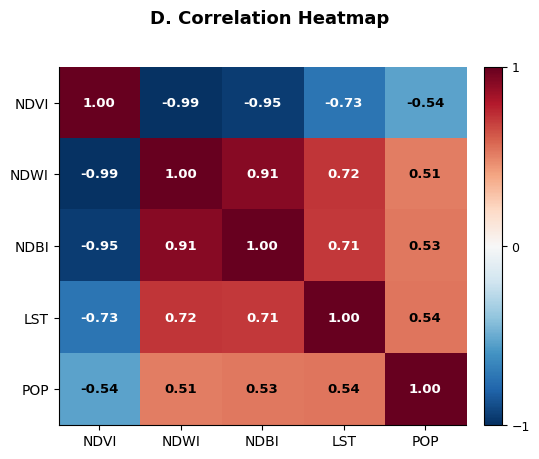

In [ ]:
# ── Correlation Heatmap (NDVI, NDWI, NDBI, LST, POP) ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

keys   = ['NDVI', 'NDWI', 'NDBI', 'LST_C', 'POP']
labels = ['NDVI', 'NDWI', 'NDBI', 'LST',   'POP']
n      = len(keys)

# Build correlation matrix
mat = np.zeros((n, n))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        mat[i, j] = np.corrcoef(data[ki], data[kj])[0, 1]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 4.5))
fig.suptitle('D. Correlation Heatmap', fontweight='bold', fontsize=13, y=1.01)

cmap = plt.get_cmap('RdBu_r')
norm = mcolors.Normalize(vmin=-1, vmax=1)
im   = ax.imshow(mat, cmap=cmap, norm=norm, aspect='auto')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_ticks([-1, 0, 1])
cbar.ax.tick_params(labelsize=9)

# Tick labels
ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=10)
ax.xaxis.set_label_position('bottom')
ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)

# Annotate cells
for i in range(n):
    for j in range(n):
        val   = mat[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=color)

plt.tight_layout()
save(fig, 'correlation_heatmap.png')

7,828 sample points
(basemap skipped: No module named 'contextily')


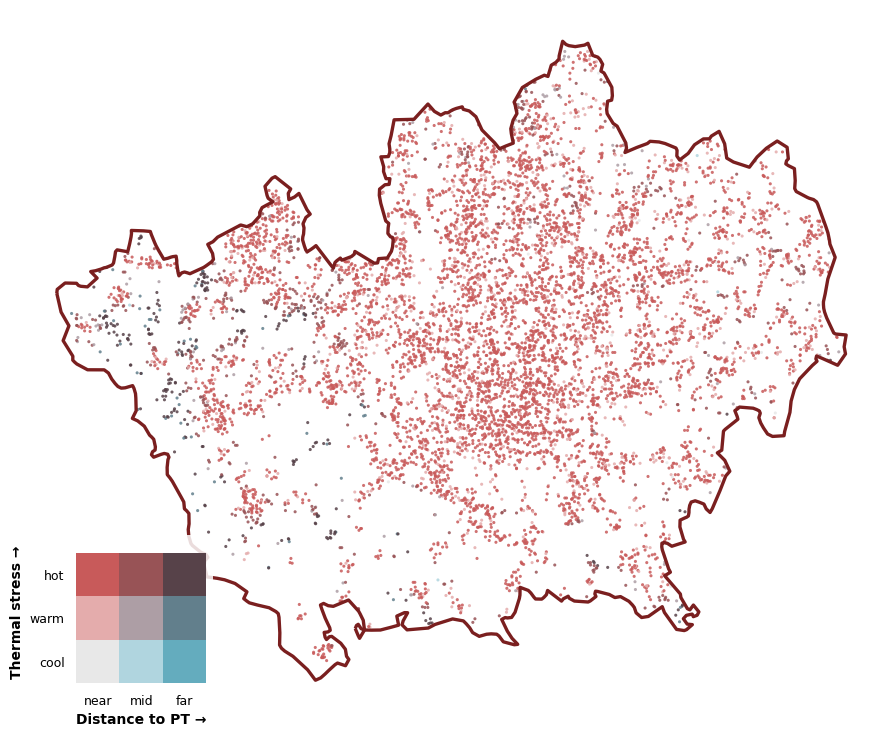

  hot:                  85.2%
  no PT (>1600 m):      3.5%
  hot + no PT:           2.9%   ← double disadvantage
  mean LST near PT:    34.50 °C
  mean LST far PT:     34.19 °C
  ΔLST (far − near):   -0.31 °C


In [ ]:
# ── Slide: Thermal stress × Public transport access (3×3 bivariate) ────────
# Reuses: region, ndvi, ndwi, ndbi, mdl, stops_gdf, city_fc, CITY, DRIVE
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import Point, shape
from sklearn.neighbors import BallTree

# Thresholds + 3×3 palette (Joshua Stevens "pink-teal")
LST_BREAKS  = (30.0, 33.0)        # cool < 30 ≤ warm < 33 ≤ hot
PT_BREAKS_M = (800, 1600)          # near < 800 ≤ mid < 1600 ≤ far
BIVAR_HEX = [
    ['#e8e8e8', '#b0d5df', '#64acbe'],   # cool · near / mid / far
    ['#e4acac', '#ad9ea5', '#627f8c'],   # warm
    ['#c85a5a', '#985356', '#574249'],   # hot
]

# 1) Build LST_pred image (same coefficients as the notebook regression).
a, b, c = (float(v) for v in mdl.coef_)
d = float(mdl.intercept_)
water_mask = (ee.Image('JRC/GSW1_4/GlobalSurfaceWater')
                .select('seasonality').gte(10).Not().unmask(1).clip(region))
lst_pred = (ndvi.multiply(a).add(ndwi.multiply(b)).add(ndbi.multiply(c))
              .add(ee.Image.constant(d))
              .updateMask(water_mask).rename('LST_pred_C'))

# 2) Sample 25 000 points — chunked because getInfo caps at 5 000 features.
coords = ee.Image.pixelLonLat().rename(['lon', 'lat'])
img    = ee.Image.cat([lst_pred, coords])
rows = []
for k in range(6):
    feats = (img.sample(region=region, scale=50, numPixels=4500,
                        seed=42 + k, dropNulls=True)
                .getInfo()['features'])
    rows.extend(f['properties'] for f in feats)
pts = (pd.DataFrame(rows)
         .rename(columns={'LST_pred_C': 'lst'})
         .drop_duplicates(subset=['lat', 'lon'])
         .reset_index(drop=True))
print(f'{len(pts):,} sample points')

# 3) Distance to nearest PT stop (BallTree haversine, in metres)
stop_rad = np.radians(stops_gdf[['lat', 'lon']].values)
pt_rad   = np.radians(pts[['lat', 'lon']].values)
dist, _  = BallTree(stop_rad, metric='haversine').query(pt_rad, k=1)
pts['dist_m'] = dist[:, 0] * 6_371_000

# 4) Bivariate class
pts['lst_class'] = np.clip(np.digitize(pts['lst'].values,    LST_BREAKS), 0, 2)
pts['pt_class']  = np.clip(np.digitize(pts['dist_m'].values, PT_BREAKS_M), 0, 2)
pts['color'] = pts.apply(
    lambda r: BIVAR_HEX[int(r['lst_class'])][int(r['pt_class'])], axis=1)

# 5) Reproject to Web Mercator for tile alignment + plot.
city_poly = shape(city_fc.getInfo()['features'][0]['geometry'])
boundary  = gpd.GeoSeries([city_poly], crs='EPSG:4326').to_crs(3857)
pts_gdf   = gpd.GeoDataFrame(
    pts,
    geometry=[Point(xy) for xy in zip(pts['lon'], pts['lat'])],
    crs='EPSG:4326',
).to_crs(3857)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_alpha(0)
ax.set_facecolor('none')

ax.scatter(pts_gdf.geometry.x, pts_gdf.geometry.y,
           s=5, c=pts['color'], linewidths=0,
           alpha=0.85, rasterized=True, zorder=2)
boundary.boundary.plot(ax=ax, color='#7a1f1f', linewidth=2.4, zorder=3)

minx, miny, maxx, maxy = boundary.total_bounds
pad = 0.04 * max(maxx - minx, maxy - miny)
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

# Optional CartoDB Positron basemap. Comment the whole try/except if you
# want a perfectly clean transparent background (no streets at all).
try:
    import contextily as cx
    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels,
                   attribution=False)
except Exception as e:
    print(f'(basemap skipped: {e})')

# ── 3×3 inset legend (lower-left, semi-transparent white background) ────────
lax = inset_axes(ax, width='22%', height='22%', loc='lower left',
                 borderpad=1.6)
lax.set_aspect('equal')
lax.set_facecolor((1, 1, 1, 0.85))
for i in range(3):
    for j in range(3):
        lax.add_patch(mpatches.Rectangle((j, i), 1, 1,
                                         facecolor=BIVAR_HEX[i][j],
                                         edgecolor='none', linewidth=0))
lax.set_xlim(-0.15, 3.15); lax.set_ylim(-0.15, 3.4)
lax.set_xticks([0.5, 1.5, 2.5]); lax.set_xticklabels(
    ['near', 'mid', 'far'], fontsize=9)
lax.set_yticks([0.5, 1.5, 2.5]); lax.set_yticklabels(
    ['cool', 'warm', 'hot'], fontsize=9)
lax.set_xlabel('Distance to PT →', fontsize=10, fontweight='bold', labelpad=4)
lax.set_ylabel('Thermal stress →', fontsize=10, fontweight='bold', labelpad=4)
for s in lax.spines.values():
    s.set_visible(False)
lax.tick_params(length=0)

fig.savefig(f'{DRIVE}/{CITY}_bivariate_stress_pt.png',
            dpi=220, bbox_inches='tight', facecolor='none', transparent=True)
plt.show()

# Numbers for the talking points
n  = len(pts)
nh = int((pts['lst_class'] == 2).sum())
nf = int((pts['pt_class']  == 2).sum())
nx = int(((pts['lst_class'] == 2) & (pts['pt_class'] == 2)).sum())
m_near = pts.loc[pts['pt_class'] == 0, 'lst'].mean()
m_far  = pts.loc[pts['pt_class'] == 2, 'lst'].mean()
print(f'  hot:                 {nh/n*100:5.1f}%')
print(f'  no PT (>{PT_BREAKS_M[1]} m):    {nf/n*100:5.1f}%')
print(f'  hot + no PT:         {nx/n*100:5.1f}%   ← double disadvantage')
print(f'  mean LST near PT:    {m_near:.2f} °C')
print(f'  mean LST far PT:     {m_far:.2f} °C')
print(f'  ΔLST (far − near):   {m_far - m_near:+.2f} °C')

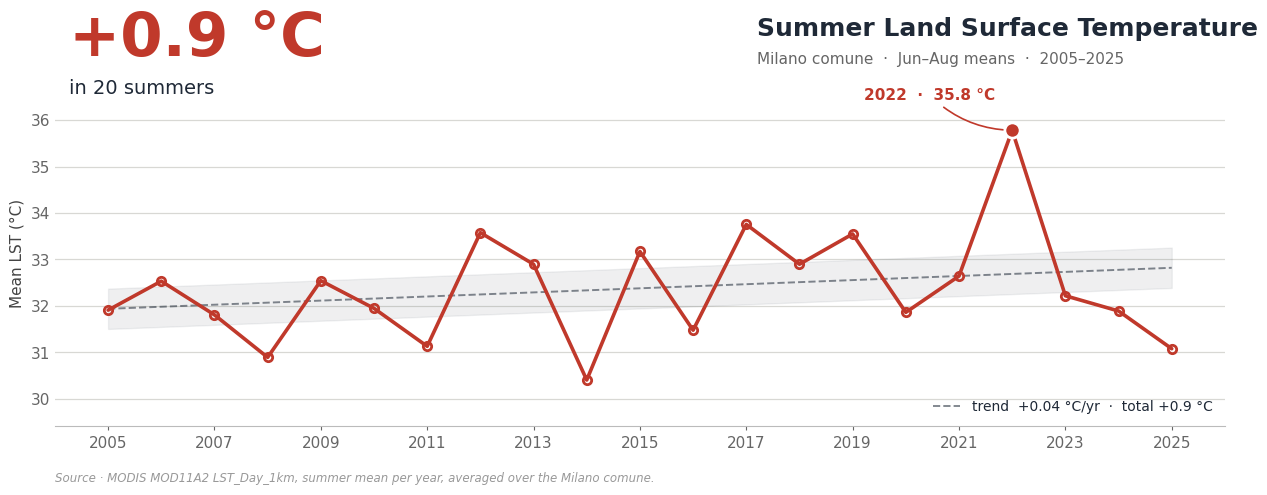


Milano  ·  2005–2025
  trend     : +0.044 °C/year   (r=+0.23, p=3.21e-01)
  total ΔT  : +0.88 °C
  hottest   : 2022  →  35.78 °C


In [ ]:
# ── Slide: 20-year evolution of summer LST in Milan  (clean aesthetic) ──────
import ee, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

HOT   = "#c0392b"
DARK  = "#1f2937"
YEARS = list(range(2005, 2026))


def yearly_mean(y):
    y = ee.Number(y)
    img = (ee.ImageCollection("MODIS/061/MOD11A2")
             .filterDate(ee.Date.fromYMD(y, 6, 1),
                         ee.Date.fromYMD(y, 9, 1))
             .select("LST_Day_1km").mean()
             .multiply(0.02).subtract(273.15))
    mean_c = img.reduceRegion(reducer=ee.Reducer.mean(),
                              geometry=region, scale=1000,
                              maxPixels=1e9, bestEffort=True
                              ).get("LST_Day_1km")
    return ee.Feature(None, {"year": y, "lst": mean_c})


fc   = ee.FeatureCollection([yearly_mean(y) for y in YEARS])
data = fc.getInfo()["features"]
df   = (pd.DataFrame([f["properties"] for f in data])
          .dropna().sort_values("year").reset_index(drop=True))
df["year"] = df["year"].astype(int)

# Stats
slope, intercept, r, p, se = stats.linregress(df["year"], df["lst"])
total_delta = slope * (df["year"].max() - df["year"].min())
hottest = df.loc[df["lst"].idxmax()]


# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":         "DejaVu Sans",
    "font.size":           11,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.spines.left":    False,
    "axes.edgecolor":      "#bbbbbb",
    "axes.labelcolor":     "#333333",
    "xtick.color":         "#666666",
    "ytick.color":         "#666666",
})

fig, ax = plt.subplots(figsize=(13, 5.6))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# ── Trend ───────────────────────────────────────────────────────────────────
xi = np.linspace(df["year"].min(), df["year"].max(), 100)
yi = slope * xi + intercept
ax.fill_between(xi, yi - se * 10, yi + se * 10,
                color=DARK, alpha=0.07, zorder=2)
ax.plot(xi, yi, "--", color=DARK, lw=1.4, alpha=0.55, zorder=3,
        label=f"trend  {slope:+.2f} °C/yr  ·  total {total_delta:+.1f} °C")

# ── Data line + markers ─────────────────────────────────────────────────────
ax.plot(df["year"], df["lst"], "-",
        color=HOT, lw=2.6, solid_capstyle="round", zorder=4)
ax.plot(df["year"], df["lst"], "o",
        color=HOT, mfc="none", mec=HOT, mew=2.0, ms=6, zorder=5)

# ── Peak year ───────────────────────────────────────────────────────────────
ax.plot(hottest["year"], hottest["lst"], "o",
        color=HOT, mfc=HOT, mec="white", mew=2.0, ms=11, zorder=6)
ax.annotate(
    f"{int(hottest['year'])}  ·  {hottest['lst']:.1f} °C",
    xy=(hottest["year"], hottest["lst"]),
    xytext=(-12, 22), textcoords="offset points",
    fontsize=11, fontweight="bold", color=HOT, ha="right",
    arrowprops=dict(arrowstyle="-", color=HOT, lw=1.2,
                    connectionstyle="arc3,rad=0.2"),
)

# ── Headline ΔT (stacked: number on top, label directly below) ──────────────
ax.text(0.012, 1.20, f"+{total_delta:.1f} °C",
        transform=ax.transAxes,
        fontsize=44, fontweight="bold", color=HOT, va="top")
ax.text(0.012, 1.00,
        f"in {df['year'].max() - df['year'].min()} summers",
        transform=ax.transAxes,
        fontsize=14, color=DARK, va="top")

# ── Title / subtitle (right side) ───────────────────────────────────────────
ax.text(0.60, 1.18,
        "Summer Land Surface Temperature",
        transform=ax.transAxes, fontsize=18, fontweight="bold",
        color=DARK, ha="left", va="top")
ax.text(0.60, 1.08,
        f"{CITY} comune  ·  Jun–Aug means  ·  "
        f"{df['year'].min()}–{df['year'].max()}",
        transform=ax.transAxes, fontsize=11, color="#666666",
        ha="left", va="top")

# ── Axes & grid ─────────────────────────────────────────────────────────────
ax.set_xticks(df["year"][::2])
ax.set_ylabel("Mean LST (°C)", fontsize=11, color="#444")
ax.set_xlabel("")
ax.set_ylim(df["lst"].min() - 1.0, df["lst"].max() + 1.1)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=3, pad=4)
ax.grid(axis="y", color="#d8d8d4", lw=0.9, zorder=0)
ax.set_axisbelow(True)

# ── Legend ──────────────────────────────────────────────────────────────────
leg = ax.legend(loc="lower right", frameon=False, fontsize=10)
for t in leg.get_texts():
    t.set_color(DARK)

# ── Method footer ───────────────────────────────────────────────────────────
ax.text(0.0, -0.16,
        "Source · MODIS MOD11A2 LST_Day_1km, summer mean per year, "
        f"averaged over the {CITY} comune.",
        transform=ax.transAxes, fontsize=8.5, color="#999",
        style="italic")

# ── Save & show ─────────────────────────────────────────────────────────────
fig.subplots_adjust(top=0.78, bottom=0.16, left=0.07, right=0.97)
fig.savefig(f"{DRIVE}/{CITY}_lst_trend_2005_2025.png",
            dpi=200, bbox_inches="tight", facecolor="none", transparent=True)
plt.show()

print(f"\n{CITY}  ·  {df['year'].min()}–{df['year'].max()}")
print(f"  trend     : {slope:+.3f} °C/year   (r={r:+.2f}, p={p:.2e})")
print(f"  total ΔT  : {total_delta:+.2f} °C")
print(f"  hottest   : {int(hottest['year'])}  →  {hottest['lst']:.2f} °C")

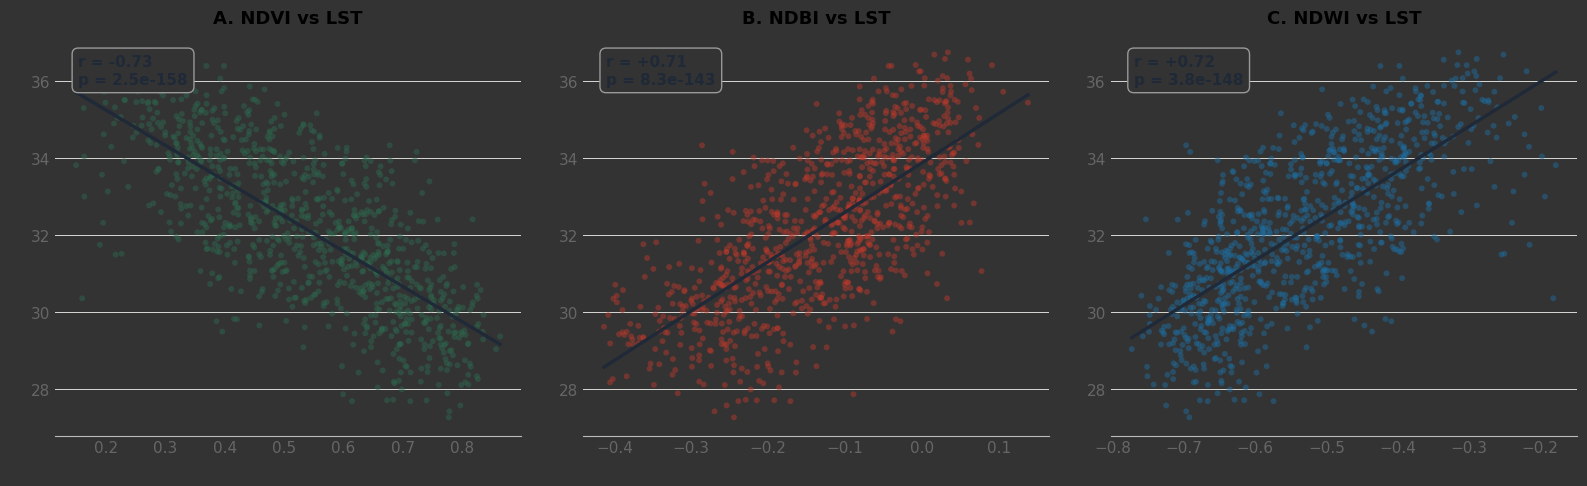


Pearson r vs LST:
  NDVI:  r = -0.734   p = 2.52e-158
  NDBI:  r = +0.709   p = 8.34e-143
  NDWI:  r = +0.718   p = 3.80e-148


In [ ]:
# ── Slide: EO Correlations — A. NDVI / B. NDBI / C. NDWI vs LST ────────────
# Uses the 1 000-point sample already in `data` from the notebook's Cell 3.
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import pandas as pd # Import pandas
import os # Ensure os is imported for os.path.exists
import pickle # Ensure pickle is imported for loading
import hashlib # Ensure hashlib is imported for cache key generation

BG    = "#333333"                    # slide background
DARK  = "#1f2937"
COLS  = {'NDVI': '#2d6a4f',
         'NDBI': '#c0392b',
         'NDWI': '#1d6fa4'}

plt.rcParams.update({
    'font.family':         'DejaVu Sans',
    'font.size':           11,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.edgecolor':      '#bbbbbb',
    'axes.labelcolor':     '#333333',
    'xtick.color':         '#666666',
    'ytick.color':         '#666666',
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

panels = [('NDVI', 'A. NDVI vs LST'),
          ('NDBI', 'B. NDBI vs LST'),
          ('NDWI', 'C. NDWI vs LST')]

# --- NEW FIX START ---
# Explicitly load the cached EO data, as 'data' might have been overwritten
_key_eo   = hashlib.md5(f'{CITY}{START}{END}'.encode()).hexdigest()[:8]
_cache_eo = f'{CACHE_DIR}/{CITY}_{_key_eo}.pkl'

if os.path.exists(_cache_eo):
    with open(_cache_eo,'rb') as f:
        eo_data = pickle.load(f)
    # Convert eo_data dictionary to DataFrame for consistent access
    eo_data_df = pd.DataFrame(eo_data)
else:
    raise FileNotFoundError(f"Cached EO data not found at {_cache_eo}. Please run cell dVmy4_EMS70t first to generate the cache.")
# --- NEW FIX END ---

for ax, (idx, title) in zip(axes, panels):
    ax.set_facecolor(BG)
    x = np.asarray(eo_data_df[idx]) # Use eo_data_df
    y = np.asarray(eo_data_df['LST_C']) # Use eo_data_df
    r, p = stats.pearsonr(x, y)

    # Scatter — one dot per sample, semi-transparent for density readability
    ax.scatter(x, y, s=18, c=COLS[idx], alpha=0.45,
               edgecolors='none', rasterized=True)

    # OLS regression line
    m, b = np.polyfit(x, y, 1)
    xi   = np.linspace(x.min(), x.max(), 100)
    ax.plot(xi, m * xi + b, color=DARK, lw=2.4)

    ax.set_title(title, fontweight='bold', fontsize=13, pad=8)
    ax.set_xlabel(idx, fontsize=11)
    ax.set_ylabel('LST (°C)', fontsize=11)
    ax.tick_params(axis='both', length=0)
    ax.grid(axis='y', color='#d8d8d4', lw=0.7, zorder=0)
    ax.set_axisbelow(True)

    p_str = f'{p:.1e}' if p > 1e-300 else '< 1e-300'
    ax.text(0.05, 0.95,
            f'r = {r:+.2f}\np = {p_str}',
            transform=ax.transAxes, va='top', ha='left',
            fontsize=11, fontweight='bold', color=DARK,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=BG, edgecolor='#999', linewidth=1.0))

fig.tight_layout()
fig.savefig(f'{DRIVE}/{CITY}_eo_correlations.png',
            dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

print('\nPearson r vs LST:')
for idx in ['NDVI', 'NDBI', 'NDWI']:
    # Use eo_data_df here as well
    r, p = stats.pearsonr(eo_data_df[idx], eo_data_df['LST_C'])
    print(f'  {idx}:  r = {r:+.3f}   p = {p:.2e}')
